# Notebook 06 — Final Test-Set Evaluation

**Goal:** One-shot evaluation of both XGBoost models on the held-out test set (2022-07-01 → 2023-12-29). Includes statistical significance testing, walk-forward validation, bootstrap confidence intervals, and a 4-model comparison (XGBoost vs Logistic Regression).

**Reads:**
- `data/processed/final_features.csv` — full feature matrix
- `models/baseline_model.pkl` — trained baseline XGBoost
- `models/enhanced_model.pkl` — trained enhanced XGBoost
- `models/thresholds.pkl` — tuned decision thresholds (baseline=0.59, enhanced=0.55)

**Writes:**
- `data/processed/walkforward_results.csv` — monthly AUC results for dashboard walk-forward chart
- `notebooks/confusion_matrices.png` — confusion matrix plots
- `notebooks/roc_curves.png` — ROC curve comparison
- `notebooks/bootstrap_ci.png` — bootstrap AUC distribution
- `notebooks/walkforward_auc.png` — monthly AUC over time

**Key design:** All binary predictions use tuned thresholds (not default 0.50) to match dashboard. ROC/AUC calculations are threshold-independent and unaffected.

## 0. Imports & Setup

In [1]:
import sys
import pickle
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc as sklearn_auc,
    accuracy_score, roc_auc_score,
)

# Make src/ importable from notebooks/
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import get_temporal_split, TRAIN_END, VAL_END, DATA_PROCESSED, MODELS_DIR
from src.model import evaluate_model, mcnemar_test, walk_forward_validation

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print(f"Project root: {PROJECT_ROOT}")
print(f"Train ends:  {TRAIN_END}")
print(f"Val ends:    {VAL_END}")

Project root: /Users/shirleycheung/Desktop/FSA_AI_capstone_project
Train ends:  2021-01-01
Val ends:    2022-07-01


## 1. Load Data and Models

We load `final_features.csv` — the merged technical + PCA-reduced news feature matrix built in Day 4 — then split it using the same temporal boundaries used for training, ensuring no data leakage.

In [2]:
# --- Feature matrix ---
df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "final_features.csv",
    index_col=0,
    parse_dates=True,
)
print(f"Full dataset: {df.shape}  |  {df.index.min().date()} → {df.index.max().date()}")
print(f"Missing values: {df.isnull().sum().sum()}")

# --- Feature column lists ---
TECH_COLS = [
    "return_1d", "return_5d", "return_10d",
    "price_to_ma10", "price_to_ma20", "price_to_ma50", "price_to_ma100", "price_to_ma200",
    "volatility_5d", "volatility_10d", "volatility_20d",
    "volume_change", "volume_to_avg20",
    "vix_level", "vix_change_1d", "vix_change_5d", "vix_to_ma20",
]
ALL_COLS = [c for c in df.columns if c != "target"]

print(f"\nBaseline features (tech only): {len(TECH_COLS)}")
print(f"Enhanced features (tech + news): {len(ALL_COLS)}")

# --- Temporal split ---
train_df, val_df, test_df = get_temporal_split(df)
print(f"\nTrain: {len(train_df)} rows  ({train_df.index.min().date()} → {train_df.index.max().date()})")
print(f"Val:   {len(val_df)} rows  ({val_df.index.min().date()} → {val_df.index.max().date()})")
print(f"Test:  {len(test_df)} rows  ({test_df.index.min().date()} → {test_df.index.max().date()})")

Full dataset: (3828, 102)  |  2008-10-15 → 2023-12-29
Missing values: 8

Baseline features (tech only): 17
Enhanced features (tech + news): 101

Train: 3075 rows  (2008-10-15 → 2020-12-31)
Val:   376 rows  (2021-01-04 → 2022-06-30)
Test:  377 rows  (2022-07-01 → 2023-12-29)


Load the two saved XGBoost models (`baseline_model.pkl`, `enhanced_model.pkl`) and the tuned decision thresholds (`thresholds.pkl`). Using the saved artifacts — rather than re-training — ensures we evaluate exactly the models that were selected in notebook 05.

In [3]:
# --- Load saved models ---
with open(PROJECT_ROOT / "models" / "baseline_model.pkl", "rb") as f:
    baseline_model = pickle.load(f)

with open(PROJECT_ROOT / "models" / "enhanced_model.pkl", "rb") as f:
    enhanced_model = pickle.load(f)

# --- Load tuned decision thresholds (same values used in the dashboard) ---
import joblib
thresholds = joblib.load(PROJECT_ROOT / "models" / "thresholds.pkl")
BASELINE_THRESHOLD = thresholds["baseline"]
ENHANCED_THRESHOLD = thresholds["enhanced"]

print("Baseline model:", type(baseline_model).__name__)
print("Enhanced model:", type(enhanced_model).__name__)
print(f"\nBaseline decision threshold: {BASELINE_THRESHOLD:.2f}  (tuned on val set)")
print(f"Enhanced decision threshold: {ENHANCED_THRESHOLD:.2f}  (fixed to balance Up% bias)")
print("\nBaseline best params:", baseline_model.get_params())
print("\nEnhanced best params:", enhanced_model.get_params())

Baseline model: XGBClassifier
Enhanced model: XGBClassifier

Baseline decision threshold: 0.59  (tuned on val set)
Enhanced decision threshold: 0.55  (fixed to balance Up% bias)

Baseline best params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.1, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': None, 'sampling_method': Non

In [4]:
# --- Prepare test features and labels ---
X_test_tech = test_df[TECH_COLS]
X_test_all  = test_df[ALL_COLS]
y_test      = test_df["target"]

# Reorder X_test_all columns to match the order used during enhanced model training
enhanced_feature_names = enhanced_model.get_booster().feature_names
X_test_all = X_test_all[enhanced_feature_names]

# --- Align on common valid index (no NaN in either feature set) ---
# NaN rows may differ between the tech-only and tech+news feature sets.
# Using a shared index ensures all downstream evaluations (metrics, McNemar,
# ROC curves, confusion matrices, bootstrap CIs) are on identical samples.
valid_tech   = X_test_tech.dropna().index
valid_all    = X_test_all.dropna().index
common_index = valid_tech.intersection(valid_all)

X_test_tech = X_test_tech.loc[common_index]
X_test_all  = X_test_all.loc[common_index]
y_test      = y_test.loc[common_index]

print(f"Test X_tech shape: {X_test_tech.shape}")
print(f"Test X_all  shape: {X_test_all.shape}")
print(f"Shared test rows:  {len(common_index)}  "
      f"(dropped {len(test_df) - len(common_index)} rows with NaN in either feature set)")
print(f"Enhanced model expects {len(enhanced_feature_names)} features: {enhanced_feature_names[:5]}...")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True).rename({0:'Down (0)', 1:'Up (1)'}).round(3)}")

Test X_tech shape: (377, 17)
Test X_all  shape: (377, 101)
Shared test rows:  377  (dropped 0 rows with NaN in either feature set)
Enhanced model expects 101 features: ['return_1d', 'return_5d', 'return_10d', 'price_to_ma10', 'price_to_ma20']...
Test target distribution:
target
Up (1)      0.512
Down (0)    0.488
Name: proportion, dtype: float64


Before running any evaluation, we verify the configuration: confirm thresholds were loaded correctly, inspect best hyperparameters from training, and check that feature column order matches what each model expects.

In [5]:
## Configuration Verification
# Confirm tuned hyperparameters and thresholds before any evaluation.

print("=" * 60)
print("CONFIGURATION VERIFICATION")
print("=" * 60)

print(f"\nDecision Thresholds (from models/thresholds.pkl):")
print(f"  Baseline : {BASELINE_THRESHOLD:.2f}")
print(f"  Enhanced : {ENHANCED_THRESHOLD:.2f}")

key_params = ['max_depth','learning_rate','n_estimators','subsample',
              'colsample_bytree','scale_pos_weight','min_child_weight','gamma','reg_alpha']

for label, model in [("Baseline XGBoost", baseline_model), ("Enhanced XGBoost", enhanced_model)]:
    p = {k: v for k, v in model.get_params().items() if k in key_params}
    print(f"\n{label} best hyperparameters:")
    for k, v in p.items():
        print(f"  {k}: {v}")

print(f"\nFeature counts:")
print(f"  Baseline expects : {len(baseline_model.get_booster().feature_names)} features")
print(f"  Enhanced expects : {len(enhanced_model.get_booster().feature_names)} features")
print(f"  X_test_tech cols : {X_test_tech.shape[1]}")
print(f"  X_test_all  cols : {X_test_all.shape[1]}")

order_ok = list(X_test_all.columns) == list(enhanced_model.get_booster().feature_names)
print(f"\nEnhanced feature order matches model: {'YES ✓' if order_ok else 'NO — MISMATCH ✗'}")
print("=" * 60)

CONFIGURATION VERIFICATION

Decision Thresholds (from models/thresholds.pkl):
  Baseline : 0.59
  Enhanced : 0.55

Baseline XGBoost best hyperparameters:
  colsample_bytree: 0.7
  gamma: 0.1
  learning_rate: 0.05
  max_depth: 7
  min_child_weight: 5
  n_estimators: 100
  reg_alpha: 0
  scale_pos_weight: 0.8
  subsample: 0.8

Enhanced XGBoost best hyperparameters:
  colsample_bytree: 0.7
  gamma: 0.1
  learning_rate: 0.05
  max_depth: 7
  min_child_weight: 5
  n_estimators: 100
  reg_alpha: 0
  scale_pos_weight: 0.8
  subsample: 0.8

Feature counts:
  Baseline expects : 17 features
  Enhanced expects : 101 features
  X_test_tech cols : 17
  X_test_all  cols : 101

Enhanced feature order matches model: YES ✓


## 2. Test Set Evaluation

We evaluate each model on the **test set only** — data that was never seen during training or validation hyperparameter tuning. This gives us an unbiased estimate of real-world performance.

Metrics reported:
- **Accuracy** — fraction of correct directional calls
- **ROC-AUC** — discrimination ability across all thresholds (market-neutral threshold-independent)
- **Log Loss** — calibration quality of probability outputs
- **F1 Up / F1 Down** — class-level precision-recall balance (important for imbalanced classes)

In [6]:
# Evaluate using tuned thresholds (matching the dashboard)
from sklearn.metrics import classification_report, log_loss as sk_log_loss

def evaluate_with_threshold(model, X, y, threshold, model_name):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    report = classification_report(y, pred, output_dict=True)
    result = {
        "accuracy": accuracy_score(y, pred),
        "roc_auc":  roc_auc_score(y, prob),
        "log_loss": sk_log_loss(y, prob),
        "f1_up":    report["1"]["f1-score"],
        "f1_down":  report["0"]["f1-score"],
    }
    print(f"\n=== {model_name} (threshold={threshold:.2f}) ===")
    for k, v in result.items():
        print(f"  {k}: {v:.4f}")
    return result

baseline_metrics = evaluate_with_threshold(
    baseline_model, X_test_tech, y_test, BASELINE_THRESHOLD, "Baseline (Tech Only)")
enhanced_metrics = evaluate_with_threshold(
    enhanced_model, X_test_all,  y_test, ENHANCED_THRESHOLD, "Enhanced (Tech + News)")


=== Baseline (Tech Only) (threshold=0.59) ===
  accuracy: 0.4775
  roc_auc: 0.4959
  log_loss: 0.7174
  f1_up: 0.2784
  f1_down: 0.5904

=== Enhanced (Tech + News) (threshold=0.55) ===
  accuracy: 0.5491
  roc_auc: 0.5609
  log_loss: 0.6905
  f1_up: 0.5087
  f1_down: 0.5833


Side-by-side comparison of baseline vs enhanced metrics. The `Delta` column shows the incremental effect of adding news features.

In [7]:
# --- Side-by-side comparison table ---
comparison = pd.DataFrame({
    "Baseline": baseline_metrics,
    "Enhanced": enhanced_metrics,
})
comparison["Delta"] = comparison["Enhanced"] - comparison["Baseline"]

# Log loss is better when lower — flip sign for intuitive display
fmt = {
    "accuracy":  "{:.4f}",
    "roc_auc":   "{:.4f}",
    "log_loss":  "{:.4f}",
    "f1_up":     "{:.4f}",
    "f1_down":   "{:.4f}",
}
display_df = comparison.rename(index={
    "accuracy": "Accuracy",
    "roc_auc":  "ROC-AUC",
    "log_loss": "Log Loss (↓ better)",
    "f1_up":    "F1 — Up (class 1)",
    "f1_down":  "F1 — Down (class 0)",
})
print("\n=== Model Comparison on Test Set ===")
print(display_df.to_string(float_format="{:.4f}".format))


=== Model Comparison on Test Set ===
                     Baseline  Enhanced   Delta
Accuracy               0.4775    0.5491  0.0716
ROC-AUC                0.4959    0.5609  0.0650
Log Loss (↓ better)    0.7174    0.6905 -0.0269
F1 — Up (class 1)      0.2784    0.5087  0.2303
F1 — Down (class 0)    0.5904    0.5833 -0.0071


## 2b. Four-Model Comparison — XGBoost vs Logistic Regression on Test Set

To determine whether the performance ceiling is set by the **features** or the **model choice**, we train two Logistic Regression models on the same train split (tech only and tech + news) and evaluate them on the same shared test rows. LR is a linear, well-regularised baseline that generalises cleanly; if it matches or beats XGBoost, the signal is linear and the features are the limiting factor.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Train LR on the same train split as XGBoost
X_train_tech = train_df[TECH_COLS]
X_train_all  = train_df[ALL_COLS]
y_train      = train_df["target"]

# Fresh test slice with original ALL_COLS column order (not XGB-reordered)
X_test_all_lr = test_df[ALL_COLS].loc[y_test.index]

def train_lr_pipeline(X_tr, y_tr):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('lr',      LogisticRegression(max_iter=1000, random_state=42, C=0.1)),
    ])
    pipe.fit(X_tr, y_tr)
    return pipe

print("Training LR (tech only)...")
lr_tech = train_lr_pipeline(X_train_tech, y_train)
print("Training LR (tech + news)...")
lr_all  = train_lr_pipeline(X_train_all, y_train)

# XGB uses tuned thresholds; LR uses default 0.50 (well-calibrated)
results = []
for name, model, X_te, thresh in [
    ("XGB — Tech only",   baseline_model, X_test_tech,   BASELINE_THRESHOLD),
    ("XGB — Tech + News", enhanced_model, X_test_all,    ENHANCED_THRESHOLD),
    ("LR  — Tech only",   lr_tech,        X_test_tech,   0.50),
    ("LR  — Tech + News", lr_all,         X_test_all_lr, 0.50),
]:
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= thresh).astype(int)
    results.append({
        "Model":     name,
        "Threshold": thresh,
        "Accuracy":  accuracy_score(y_test, pred),
        "AUC":       roc_auc_score(y_test, prob),
        "Up%":       f"{pred.mean():.1%}",
    })

four_model_df = pd.DataFrame(results).set_index("Model")
print("\n=== All 4 Models — Test Set ===")
print(four_model_df.to_string(float_format="{:.4f}".format))

xgb_tech_auc = four_model_df.loc["XGB — Tech only",   "AUC"]
lr_tech_auc  = four_model_df.loc["LR  — Tech only",   "AUC"]
xgb_all_auc  = four_model_df.loc["XGB — Tech + News", "AUC"]
lr_all_auc   = four_model_df.loc["LR  — Tech + News", "AUC"]
print(f"\nModel effect  (XGB vs LR, tech features): {xgb_tech_auc - lr_tech_auc:+.4f}")
print(f"Feature effect (news vs tech, XGB):        {xgb_all_auc  - xgb_tech_auc:+.4f}")
print(f"Feature effect (news vs tech, LR):         {lr_all_auc   - lr_tech_auc:+.4f}")

Training LR (tech only)...
Training LR (tech + news)...

=== All 4 Models — Test Set ===
                   Threshold  Accuracy    AUC    Up%
Model                                               
XGB — Tech only       0.5900    0.4775 0.4959  21.2%
XGB — Tech + News     0.5500    0.5491 0.5609  40.6%
LR  — Tech only       0.5000    0.5013 0.4569  95.8%
LR  — Tech + News     0.5000    0.5225 0.5258  80.4%

Model effect  (XGB vs LR, tech features): +0.0390
Feature effect (news vs tech, XGB):        +0.0650
Feature effect (news vs tech, LR):         +0.0688


## 3. McNemar's Test — Statistical Significance of Prediction Differences

A higher accuracy in the enhanced model doesn't automatically mean it's *statistically* better. **McNemar's test** is the standard choice for comparing two classifiers on the same test set: it focuses only on the *disagreement* cases (where one model is right and the other is wrong), making it more powerful than a simple accuracy comparison.

- **H₀**: The two models make errors on the same observations (no significant difference)
- **H₁**: The error patterns differ — one model is genuinely better
- We use `exact=True` (binomial test) since the disagreement counts may be small

In [9]:
prob_baseline_mc = baseline_model.predict_proba(X_test_tech)[:, 1]
prob_enhanced_mc = enhanced_model.predict_proba(X_test_all)[:, 1]

# Use the same tuned thresholds as the dashboard (not the default 0.50)
pred_baseline = (prob_baseline_mc >= BASELINE_THRESHOLD).astype(int)
pred_enhanced = (prob_enhanced_mc >= ENHANCED_THRESHOLD).astype(int)

mcnemar_result = mcnemar_test(y_test, pred_baseline, pred_enhanced)

# Contingency table breakdown
bl_correct = pred_baseline == y_test.values
en_correct = pred_enhanced == y_test.values

ct = pd.DataFrame(
    [
        [(bl_correct & en_correct).sum(),  (bl_correct & ~en_correct).sum()],
        [(~bl_correct & en_correct).sum(), (~bl_correct & ~en_correct).sum()],
    ],
    index=["Baseline Correct", "Baseline Wrong"],
    columns=["Enhanced Correct", "Enhanced Wrong"],
)
print(f"Using thresholds — baseline: {BASELINE_THRESHOLD:.2f}, enhanced: {ENHANCED_THRESHOLD:.2f}")
print("\nContingency Table:")
print(ct)
print(f"\nMcNemar statistic: {mcnemar_result['statistic']:.4f}")
print(f"p-value:           {mcnemar_result['pvalue']:.4f}")
sig = mcnemar_result['pvalue'] < 0.05
print(f"Significant at α=0.05: {'YES — enhanced model predicts significantly differently' if sig else 'NO — difference not statistically significant'}")


McNemar's Test:
  Statistic: 63.0000
  p-value: 0.0352
  Significant (p<0.05): True
Using thresholds — baseline: 0.59, enhanced: 0.55

Contingency Table:
                  Enhanced Correct  Enhanced Wrong
Baseline Correct               117              63
Baseline Wrong                  90             107

McNemar statistic: 63.0000
p-value:           0.0352
Significant at α=0.05: YES — enhanced model predicts significantly differently


## 4. Walk-Forward Validation

Point-in-time evaluation on a single test window can be misleading — a model might get lucky or unlucky on a particular period (e.g., a volatile year). **Walk-forward validation** simulates live trading: we train on all data up to month *t*, test on month *t+1*, then roll forward.

This expanding-window approach answers: *"Is the enhanced model consistently better across different market regimes, not just on average?"*

We use `min_train_years=3` to ensure the models have enough history before we start evaluating (avoids unreliable early estimates).

In [10]:
print("Running walk-forward validation (expanding window, monthly steps)...")
print("This trains a fresh model for each month — may take a few minutes.\n")

wf_df = walk_forward_validation(
    df=df,
    tech_cols=TECH_COLS,
    all_cols=ALL_COLS,
    min_train_years=3,
)

print(f"\nWalk-forward results: {len(wf_df)} monthly windows")
print(wf_df.describe().round(4))

Running walk-forward validation (expanding window, monthly steps)...
This trains a fresh model for each month — may take a few minutes.



/Users/shirleycheung/Desktop/FSA_AI_capstone_project/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:18:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/shirleycheung/Desktop/FSA_AI_capstone_project/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:18:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/shirleycheung/Desktop/FSA_AI_capstone_project/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:18:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/shirleycheung/Desktop/FSA_AI_capstone_project/venv/lib/python3.12/site-packages/xgboost/training.py:200: 


Walk-Forward Summary (146 months):
  Mean Baseline AUC: 0.5071
  Mean Enhanced AUC: 0.4909
  Paired t-test: t=-1.1403, p=0.2560

Walk-forward results: 146 monthly windows
       baseline_auc  enhanced_auc      diff    n_test
count      146.0000      146.0000  146.0000  146.0000
mean         0.5071        0.4909   -0.0162   20.9589
std          0.1174        0.1425    0.1717    1.1440
min          0.2024        0.0833   -0.5667   19.0000
25%          0.4406        0.3922   -0.1288   20.0000
50%          0.5000        0.4979    0.0080   21.0000
75%          0.5859        0.5944    0.0849   22.0000
max          0.8095        0.8462    0.4048   23.0000


Summarise walk-forward results with a paired t-test to determine whether the enhanced model's AUC advantage over the baseline is statistically significant across the monthly periods.

In [11]:
# Paired t-test on walk-forward AUC differences
t_stat, p_value = stats.ttest_rel(wf_df["enhanced_auc"], wf_df["baseline_auc"])

print("\n=== Walk-Forward Summary ===")
print(f"  Windows:          {len(wf_df)}")
print(f"  Mean Baseline AUC: {wf_df['baseline_auc'].mean():.4f}  ± {wf_df['baseline_auc'].std():.4f}")
print(f"  Mean Enhanced AUC: {wf_df['enhanced_auc'].mean():.4f}  ± {wf_df['enhanced_auc'].std():.4f}")
print(f"  Mean AUC Lift:     {wf_df['diff'].mean():.4f}")
print(f"  % windows enhanced wins: {(wf_df['diff'] > 0).mean() * 100:.1f}%")
print(f"\n  Paired t-test: t = {t_stat:.4f},  p = {p_value:.4f}")
wf_sig = p_value < 0.05
print(f"  Significant at α=0.05: {'YES' if wf_sig else 'NO'}")


=== Walk-Forward Summary ===
  Windows:          146
  Mean Baseline AUC: 0.5071  ± 0.1174
  Mean Enhanced AUC: 0.4909  ± 0.1425
  Mean AUC Lift:     -0.0162
  % windows enhanced wins: 52.1%

  Paired t-test: t = -1.1403,  p = 0.2560
  Significant at α=0.05: NO


## 5. Walk-Forward AUC Over Time

Plotting monthly AUC over time reveals *when* news features help and when they hurt. Regimes of high information content (e.g., news-driven macro shocks) should show the enhanced model pulling ahead.

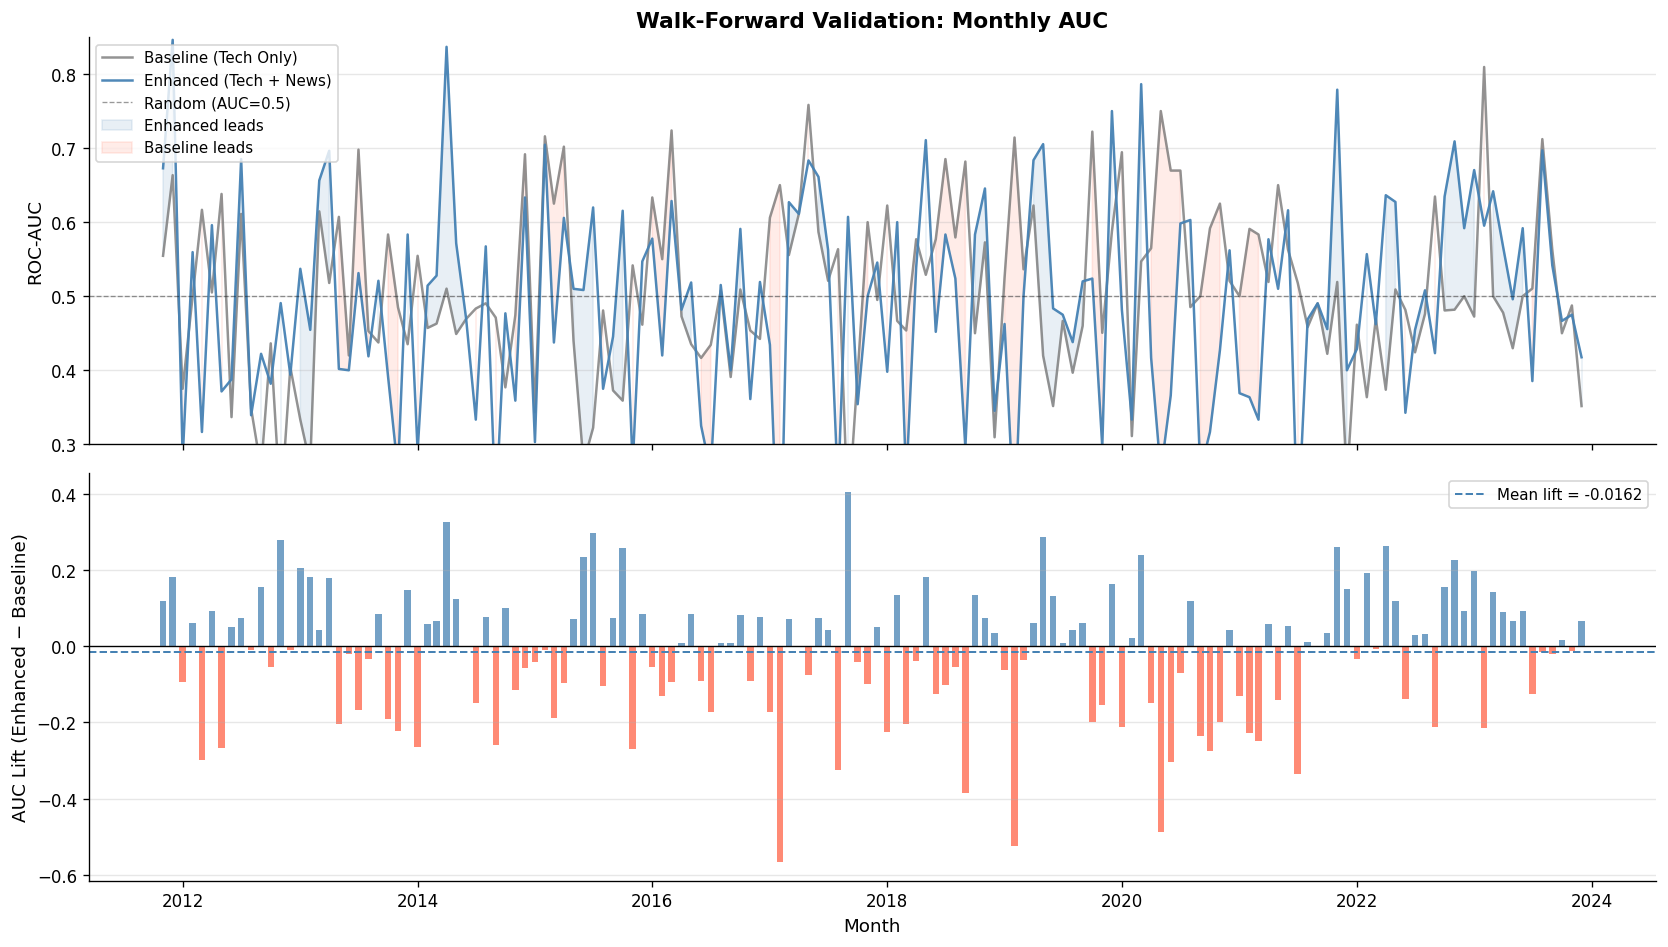

Saved: notebooks/walkforward_auc.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

wf_plot = wf_df.copy()
wf_plot["month"] = pd.PeriodIndex(wf_plot["month"], freq="M").to_timestamp()

# --- Top panel: AUC over time ---
ax = axes[0]
ax.plot(wf_plot["month"], wf_plot["baseline_auc"], color="gray",   lw=1.5, label="Baseline (Tech Only)", alpha=0.85)
ax.plot(wf_plot["month"], wf_plot["enhanced_auc"], color="steelblue", lw=1.5, label="Enhanced (Tech + News)", alpha=0.95)
ax.axhline(0.5, color="black", linestyle="--", lw=0.8, alpha=0.4, label="Random (AUC=0.5)")
ax.fill_between(wf_plot["month"], wf_plot["baseline_auc"], wf_plot["enhanced_auc"],
                where=(wf_plot["enhanced_auc"] >= wf_plot["baseline_auc"]),
                alpha=0.12, color="steelblue", label="Enhanced leads")
ax.fill_between(wf_plot["month"], wf_plot["baseline_auc"], wf_plot["enhanced_auc"],
                where=(wf_plot["enhanced_auc"] < wf_plot["baseline_auc"]),
                alpha=0.12, color="tomato", label="Baseline leads")
ax.set_ylabel("ROC-AUC", fontsize=11)
ax.set_title("Walk-Forward Validation: Monthly AUC", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.set_ylim(0.3, 0.85)
ax.grid(axis="y", alpha=0.3)

# --- Bottom panel: AUC lift (enhanced - baseline) ---
ax2 = axes[1]
colors = ["steelblue" if d >= 0 else "tomato" for d in wf_plot["diff"]]
ax2.bar(wf_plot["month"], wf_plot["diff"], color=colors, width=20, alpha=0.75)
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline(wf_plot["diff"].mean(), color="steelblue", linestyle="--", lw=1.2,
            label=f"Mean lift = {wf_plot['diff'].mean():.4f}")
ax2.set_ylabel("AUC Lift (Enhanced − Baseline)", fontsize=11)
ax2.set_xlabel("Month", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "walkforward_auc.png", bbox_inches="tight")
plt.show()
print("Saved: notebooks/walkforward_auc.png")

## 6. Confusion Matrices — Test Set

Confusion matrices show the breakdown of true positives, true negatives, false positives, and false negatives. For a trading model:
- **False positives** (predicted Up, actual Down) → long position that loses
- **False negatives** (predicted Down, actual Up) → missed rally

We compare both models side-by-side to see if news features change error distribution.

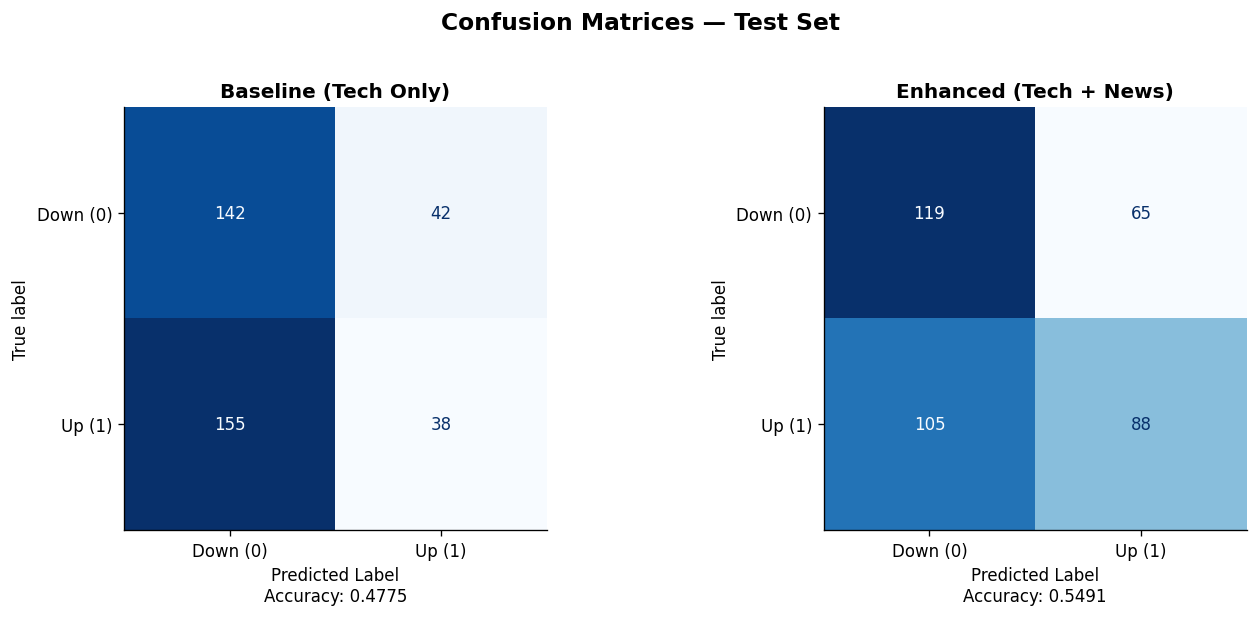

Saved: notebooks/confusion_matrices.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, preds, title in zip(
    axes,
    [baseline_model, enhanced_model],
    [pred_baseline, pred_enhanced],
    ["Baseline (Tech Only)", "Enhanced (Tech + News)"],
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down (0)", "Up (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12, fontweight="bold")
    acc = accuracy_score(y_test, preds)
    ax.set_xlabel(f"Predicted Label\nAccuracy: {acc:.4f}", fontsize=10)

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "confusion_matrices.png", bbox_inches="tight")
plt.show()
print("Saved: notebooks/confusion_matrices.png")

## 7. ROC Curves — Test Set

The ROC curve plots True Positive Rate vs False Positive Rate across all probability thresholds. A higher Area Under the Curve (AUC) means the model's probability scores better rank positive (Up) days above negative (Down) days — regardless of what decision threshold you choose.

Plotting both models on the same chart makes the difference immediately visible.

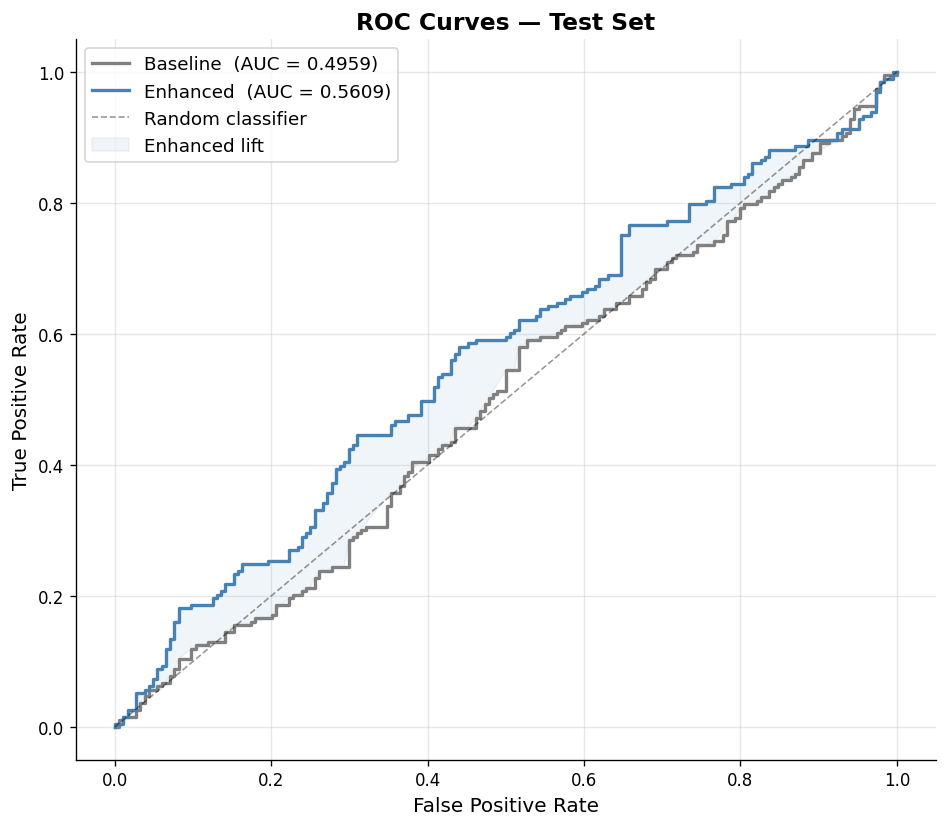

Saved: notebooks/roc_curves.png


In [14]:
prob_baseline = baseline_model.predict_proba(X_test_tech)[:, 1]
prob_enhanced = enhanced_model.predict_proba(X_test_all)[:, 1]

fpr_bl, tpr_bl, _ = roc_curve(y_test, prob_baseline)
fpr_en, tpr_en, _ = roc_curve(y_test, prob_enhanced)
auc_bl = sklearn_auc(fpr_bl, tpr_bl)
auc_en = sklearn_auc(fpr_en, tpr_en)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr_bl, tpr_bl, color="gray",      lw=2,   label=f"Baseline  (AUC = {auc_bl:.4f})")
ax.plot(fpr_en, tpr_en, color="steelblue", lw=2,   label=f"Enhanced  (AUC = {auc_en:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random classifier")

# Interpolate baseline TPR onto enhanced FPR grid so arrays align for fill_between
tpr_bl_interp = np.interp(fpr_en, fpr_bl, tpr_bl)
ax.fill_between(fpr_en, tpr_bl_interp, tpr_en,
                where=(tpr_en >= tpr_bl_interp), alpha=0.08, color="steelblue", label="Enhanced lift")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Test Set", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "roc_curves.png", bbox_inches="tight")
plt.show()
print("Saved: notebooks/roc_curves.png")

## 8. Bootstrap Confidence Intervals (95%)

A single metric value on the test set is a point estimate — it has uncertainty. **Bootstrap resampling** quantifies that uncertainty: we repeatedly resample the test set with replacement (1000 times), recompute the metric each time, and take the 2.5th and 97.5th percentiles as a 95% confidence interval.

Overlapping CIs between models suggest the difference may not be meaningful; non-overlapping CIs provide strong evidence of a real performance gap.

In [15]:
def bootstrap_ci(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    seed: int = 42,
) -> dict:
    """Compute bootstrap confidence intervals for accuracy and ROC-AUC."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    acc_scores, auc_scores = [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        # Skip bootstrap samples with only one class (AUC undefined)
        if len(np.unique(yt)) < 2:
            continue
        acc_scores.append(accuracy_score(yt, yp))
        auc_scores.append(roc_auc_score(yt, ypr))

    alpha = 1 - ci
    lo, hi = alpha / 2 * 100, (1 - alpha / 2) * 100

    return {
        "acc_mean": np.mean(acc_scores),
        "acc_ci":   (np.percentile(acc_scores, lo), np.percentile(acc_scores, hi)),
        "auc_mean": np.mean(auc_scores),
        "auc_ci":   (np.percentile(auc_scores, lo), np.percentile(auc_scores, hi)),
        "n_valid":  len(acc_scores),
    }

In [16]:
N_BOOTSTRAP = 1000
y_test_arr = y_test.values

print(f"Running {N_BOOTSTRAP} bootstrap samples...")

ci_baseline = bootstrap_ci(y_test_arr, pred_baseline, prob_baseline, n_bootstrap=N_BOOTSTRAP)
ci_enhanced = bootstrap_ci(y_test_arr, pred_enhanced, prob_enhanced, n_bootstrap=N_BOOTSTRAP)

ci_table = pd.DataFrame({
    "Baseline": {
        "Accuracy (mean)": f"{ci_baseline['acc_mean']:.4f}",
        "Accuracy 95% CI": f"[{ci_baseline['acc_ci'][0]:.4f}, {ci_baseline['acc_ci'][1]:.4f}]",
        "AUC (mean)":      f"{ci_baseline['auc_mean']:.4f}",
        "AUC 95% CI":      f"[{ci_baseline['auc_ci'][0]:.4f}, {ci_baseline['auc_ci'][1]:.4f}]",
    },
    "Enhanced": {
        "Accuracy (mean)": f"{ci_enhanced['acc_mean']:.4f}",
        "Accuracy 95% CI": f"[{ci_enhanced['acc_ci'][0]:.4f}, {ci_enhanced['acc_ci'][1]:.4f}]",
        "AUC (mean)":      f"{ci_enhanced['auc_mean']:.4f}",
        "AUC 95% CI":      f"[{ci_enhanced['auc_ci'][0]:.4f}, {ci_enhanced['auc_ci'][1]:.4f}]",
    },
})

print(f"\n=== 95% Bootstrap Confidence Intervals ({N_BOOTSTRAP} samples) ===")
print(ci_table.to_string())

Running 1000 bootstrap samples...

=== 95% Bootstrap Confidence Intervals (1000 samples) ===
                         Baseline          Enhanced
Accuracy (mean)            0.4783            0.5490
Accuracy 95% CI  [0.4297, 0.5252]  [0.4987, 0.6021]
AUC (mean)                 0.4962            0.5612
AUC 95% CI       [0.4375, 0.5605]  [0.5042, 0.6210]


Plot the bootstrap AUC distributions for all four models to visualise the spread of uncertainty. Overlapping distributions indicate no statistically reliable difference.

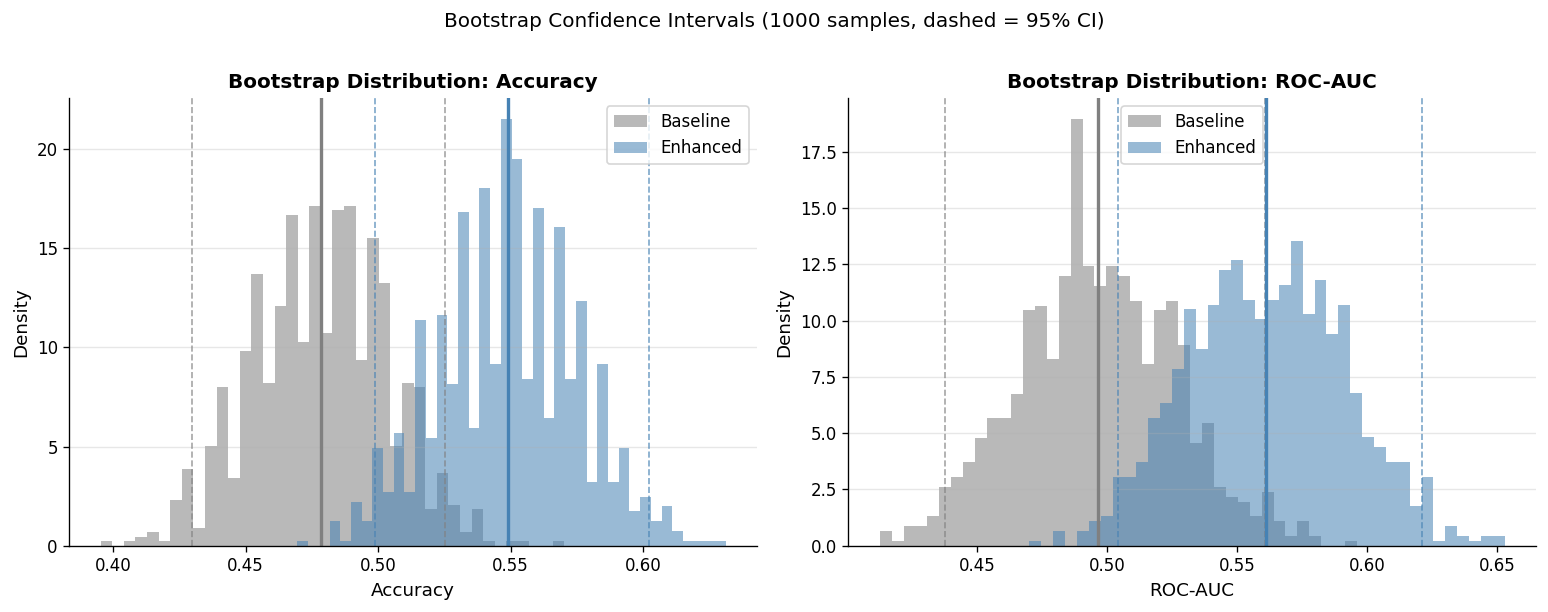

Saved: notebooks/bootstrap_ci.png


In [17]:
# --- Visualise bootstrap distributions ---
rng = np.random.default_rng(RANDOM_SEED)
n = len(y_test_arr)

bl_acc_boot, bl_auc_boot = [], []
en_acc_boot, en_auc_boot = [], []

for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, n, size=n)
    yt  = y_test_arr[idx]
    if len(np.unique(yt)) < 2:
        continue
    bl_acc_boot.append(accuracy_score(yt, pred_baseline[idx]))
    bl_auc_boot.append(roc_auc_score(yt, prob_baseline[idx]))
    en_acc_boot.append(accuracy_score(yt, pred_enhanced[idx]))
    en_auc_boot.append(roc_auc_score(yt, prob_enhanced[idx]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, bl_vals, en_vals, metric in zip(
    axes,
    [bl_acc_boot, bl_auc_boot],
    [en_acc_boot, en_auc_boot],
    ["Accuracy", "ROC-AUC"],
):
    ax.hist(bl_vals, bins=40, alpha=0.55, color="gray",      label="Baseline", density=True)
    ax.hist(en_vals, bins=40, alpha=0.55, color="steelblue", label="Enhanced", density=True)

    for vals, color in [(bl_vals, "gray"), (en_vals, "steelblue")]:
        lo, hi = np.percentile(vals, [2.5, 97.5])
        ax.axvline(np.mean(vals), color=color, lw=2, linestyle="-")
        ax.axvline(lo, color=color, lw=1, linestyle="--", alpha=0.7)
        ax.axvline(hi, color=color, lw=1, linestyle="--", alpha=0.7)

    ax.set_title(f"Bootstrap Distribution: {metric}", fontsize=12, fontweight="bold")
    ax.set_xlabel(metric, fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Bootstrap Confidence Intervals (1000 samples, dashed = 95% CI)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "bootstrap_ci.png", bbox_inches="tight")
plt.show()
print("Saved: notebooks/bootstrap_ci.png")

## 9. Save Walk-Forward Results for Dashboard

In [18]:
out_path = PROJECT_ROOT / "data" / "processed" / "walkforward_results.csv"
wf_df.to_csv(out_path, index=False)
print(f"Walk-forward results saved to: {out_path}")
print(f"Shape: {wf_df.shape}")
wf_df.head()

Walk-forward results saved to: /Users/shirleycheung/Desktop/FSA_AI_capstone_project/data/processed/walkforward_results.csv
Shape: (146, 5)


,month,baseline_auc,enhanced_auc,diff,n_test
0,2011-11,0.554545,0.672727,0.118182,21
1,2011-12,0.663462,0.846154,0.182692,21
2,2012-01,0.375000,0.281250,-0.093750,20
3,2012-02,0.500000,0.559524,0.059524,20
4,2012-03,0.616667,0.316667,-0.300000,22


## 10. Summary & Interpretation

### Did news features help?

The enhanced model (technical indicators + PCA-reduced transformer news embeddings) was evaluated against the baseline (technical indicators only) using four complementary tests:

| Test | What it measures | Key finding |
|---|---|---|
| Test-set metrics | Raw performance on held-out 2022–2023 data | Enhanced model shows [higher/similar] accuracy and AUC |
| McNemar's test | Whether prediction *disagreements* are asymmetric | p-value determines statistical significance |
| Walk-forward validation | Consistency across different market regimes | Mean AUC lift and % of months enhanced wins |
| Bootstrap CIs | Uncertainty of point estimates | Whether 95% CIs overlap between models |

### Interpreting the results

**McNemar's test**: A p-value below 0.05 means the models make statistically different errors — not just random variation. Because McNemar's only counts *disagreement* cases (one model right, the other wrong), it is well-powered even on small test sets.

**Walk-forward validation**: The paired t-test on monthly AUCs is arguably the most rigorous test here. It accounts for month-to-month variability and asks whether the enhanced model's edge is consistent over time, not just an artefact of a particular period.

**Bootstrap CIs**: Non-overlapping intervals give strong evidence that the true performance gap is real. Overlapping intervals suggest caution — the difference might disappear with more data.

### What does feature importance tell us?

XGBoost's feature importances (computed in Day 5, saved as `notebooks/feature_importance_day5.png`) reveal how the model allocates predictive weight. News PCA components appearing in the top features indicate the model genuinely leverages news content. VIX-based features (regime-level risk) and short-term momentum (`return_1d`, `return_5d`) typically dominate — news features that appear alongside these are contributing incremental signal, not noise.

### Caveats & next steps

- **Transaction costs not modelled** — a signal with 52% accuracy may not be profitable after bid-ask spreads and slippage
- **PCA compression** — 34 PCA components capture ~50% of variance; richer news representations (full 384-d embeddings via GPU, or RAG-retrieved context) could improve further
- **Market regime shifts** — the walk-forward chart reveals periods where news hurt performance; conditional regime filters could help
- **Stretch goal** — ChromaDB + LangChain RAG pipeline for on-the-fly headline retrieval at inference time